## 1️⃣ Setup

### 1.1) Imports

In [1]:
import pandas as pd
import numpy as np
import os


# Import for special characters (Mojibake)
from ftfy import fix_text

### 1.2) Get the data 📕

The data is available on Kagle, but on our case it was downloaded and saved inside **folder raw_data** as **winemag-data-130k-v2.csv** 

In [2]:
# Data pulled into a Pandas DataFrame

df = pd.read_csv('../raw_data/winemag-data-130k-v2.csv')
df.head()

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


### 1.3) Have a look at the data 🔎

In [3]:
# Check the non-null count and data types for each column

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129971 entries, 0 to 129970
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             129971 non-null  int64  
 1   country                129908 non-null  object 
 2   description            129971 non-null  object 
 3   designation            92506 non-null   object 
 4   points                 129971 non-null  int64  
 5   price                  120975 non-null  float64
 6   province               129908 non-null  object 
 7   region_1               108724 non-null  object 
 8   region_2               50511 non-null   object 
 9   taster_name            103727 non-null  object 
 10  taster_twitter_handle  98758 non-null   object 
 11  title                  129971 non-null  object 
 12  variety                129970 non-null  object 
 13  winery                 129971 non-null  object 
dtypes: float64(1), int64(2), object(11)


## 2️⃣ Preprocessing

In [4]:
# Create a copy of the original DataFrame to work with
wine_clean = df.copy()

## 2.1) Check missing values

In [5]:
# Check number of missing values in each column
wine_clean.isna().sum()

Unnamed: 0                   0
country                     63
description                  0
designation              37465
points                       0
price                     8996
province                    63
region_1                 21247
region_2                 79460
taster_name              26244
taster_twitter_handle    31213
title                        0
variety                      1
winery                       0
dtype: int64

In [6]:
# Check the % of missing values in each column, rounded by 2 decimal places.

(wine_clean.isna().mean() * 100).round(2)

Unnamed: 0                0.00
country                   0.05
description               0.00
designation              28.83
points                    0.00
price                     6.92
province                  0.05
region_1                 16.35
region_2                 61.14
taster_name              20.19
taster_twitter_handle    24.02
title                     0.00
variety                   0.00
winery                    0.00
dtype: float64

## 2.2) Fix mojibake (accent corruption and special character)

In [ ]:
# All the columns with text data types will be converted to string and cleaned using the fix_text function from the ftfy library.
# This will help to correct any mojibake or encoding issues in the text data.
# When it converts to string the empty values will be converted to 'nan' string, so we will convert them to NaN after the fix_text function is applied.

import numpy as np

# Create list with all Object columns (text columns) in the DataFrame
text_cols = [
    "country", "description", "designation", "province",
    "region_1", "region_2", "taster_name", "taster_twitter_handle",
    "title", "variety", "winery"
]

for col in text_cols:
    wine_clean[col] = wine_clean[col].astype(str).apply(fix_text)

# Convert 'nan' strings back to NaN
wine_clean = wine_clean.replace('nan', np.nan)


## 2.2  Drop columns that will not be need it

In [ ]:
## The collums Unnamed: 0, description, taster_twitter_handle are not useful for our analysis and have a high % of missing valuesso we will drop them.
drop_columns = ["Unnamed: 0","designation", "region_2","taster_twitter_handle"]

wine_clean =wine_clean.drop(columns=drop_columns)


In [9]:
wine_clean.columns.tolist()

['country',
 'description',
 'points',
 'price',
 'province',
 'region_1',
 'taster_name',
 'title',
 'variety',
 'winery']

## 2.3) Check duplicated rows

In [10]:
# Duplicated rows based on description text and title
dups = wine_clean[wine_clean.duplicated(subset=["title", "description"], keep=False)]

print("Duplicated rows based on description and title:", dups.shape[0])


Duplicated rows based on description and title: 19966


In [11]:
# Drop duplicates based on description and title.

before = len(wine_clean)
wine_clean = wine_clean.drop_duplicates(subset=["title", "description"])
after = len(wine_clean)
print(f"Duplicate rows removed: {before - after}")

Duplicate rows removed: 9983


## 2.4 Handle missing values

In [12]:
# Check the number of missing values in each column

wine_clean.isna().sum()

country           59
description        0
points             0
price           8395
province          59
region_1       19560
taster_name    24917
title              0
variety            1
winery             0
dtype: int64

# 2.4.1 - Price Column

In [13]:
# For Price the null values will be dropped, as the price is a key feature for the recommender system. For the other columns, the null values will be filled with 'Unknown' for categorical columns and 0 for numerical columns.
wine_clean = wine_clean.dropna(subset=["price"]).copy()

wine_clean[wine_clean["price"].isna()]

,country,description,points,price,province,region_1,taster_name,title,variety,winery


# 2.4.2 - Country Column

In [14]:
wine_clean["country"].unique()

array(['Portugal', 'US', 'Spain', 'Italy', 'France', 'Germany',
       'Argentina', 'Chile', 'Australia', 'Austria', 'South Africa',
       'New Zealand', 'Israel', 'Hungary', 'Greece', 'Romania', 'Mexico',
       'Canada', nan, 'Turkey', 'Czech Republic', 'Slovenia',
       'Luxembourg', 'Croatia', 'Georgia', 'Uruguay', 'England',
       'Lebanon', 'Serbia', 'Brazil', 'Moldova', 'Morocco', 'Peru',
       'India', 'Bulgaria', 'Cyprus', 'Armenia', 'Switzerland',
       'Bosnia and Herzegovina', 'Ukraine', 'Slovakia', 'Macedonia',
       'China'], dtype=object)

In [15]:
# For the country the null values will be replace according with the winery Location.
wine_clean.loc[wine_clean["winery"] == "Gotsa Family Wines", "country"] = "Georgia"
wine_clean.loc[wine_clean["winery"] == "Barton & Guestier", "country"] = "France"
wine_clean.loc[wine_clean["winery"] == "Kakhetia Traditional Winemaking", "country"] = "Georgia"
wine_clean.loc[wine_clean["winery"] == "Tsililis", "country"] = "Greece"
wine_clean.loc[wine_clean["winery"] == "Ross-idi", "country"] = "Bulgaria"
wine_clean.loc[wine_clean["winery"] == "Les Frères Dutruy", "country"] = "Switzerland"
wine_clean.loc[wine_clean["winery"] == "El Capricho", "country"] = "Spain"
wine_clean.loc[wine_clean["winery"] == "Büyülübağ", "country"] = "Turkey"
wine_clean.loc[wine_clean["winery"] == "Psagot", "country"] = "Israel"
wine_clean.loc[wine_clean["winery"] == "Orbelus", "country"] = "Bulgaria"
wine_clean.loc[wine_clean["winery"] == "St. Donat", "country"] = "Hungary"
wine_clean.loc[wine_clean["winery"] == "Familia Deicas", "country"] = "Uruguay"
wine_clean.loc[wine_clean["winery"] == "Bartho Eksteen", "country"] = "South Africa"
wine_clean.loc[wine_clean["winery"] == "Stone Castle", "country"] = "Kosovo"
wine_clean.loc[wine_clean["winery"] == "Teliani Valley", "country"] = "Georgia"
wine_clean.loc[wine_clean["winery"] == "Undurraga", "country"] = "Chile"
wine_clean.loc[wine_clean["winery"] == "Mt. Beautiful", "country"] = "New Zealand"
wine_clean.loc[wine_clean["winery"] == "Neumeister", "country"] = "Austria"
wine_clean.loc[wine_clean["winery"] == "Bachelder", "country"] = "Canada"
wine_clean.loc[wine_clean["winery"] == "Chilcas", "country"] = "Chile"
wine_clean.loc[wine_clean["winery"] == "Santa Ema", "country"] = "Chile"
wine_clean.loc[wine_clean["winery"] == "Newton Johnson", "country"] = "South Africa"
wine_clean.loc[wine_clean["winery"] == "Ktima Voyatzi", "country"] = "Greece"
wine_clean.loc[wine_clean["winery"] == "Lismore", "country"] = "South Africa"
wine_clean.loc[wine_clean["winery"] == "Logodaj", "country"] = "Bulgaria"
wine_clean.loc[wine_clean["winery"] == "Somlói Vándor", "country"] = "Hungary"
wine_clean.loc[wine_clean["winery"] == "Amiran Vepkhvadze", "country"] = "Georgia"

wine_clean[wine_clean["country"].isna()]


,country,description,points,price,province,region_1,taster_name,title,variety,winery


In [16]:
wine_clean["country"].unique()

array(['Portugal', 'US', 'Spain', 'Italy', 'France', 'Germany',
       'Argentina', 'Chile', 'Australia', 'Austria', 'South Africa',
       'New Zealand', 'Israel', 'Hungary', 'Greece', 'Romania', 'Mexico',
       'Canada', 'Georgia', 'Turkey', 'Czech Republic', 'Slovenia',
       'Luxembourg', 'Croatia', 'Uruguay', 'England', 'Lebanon', 'Serbia',
       'Brazil', 'Moldova', 'Morocco', 'Peru', 'India', 'Bulgaria',
       'Cyprus', 'Armenia', 'Switzerland', 'Bosnia and Herzegovina',
       'Ukraine', 'Slovakia', 'Macedonia', 'Kosovo', 'China'],
      dtype=object)

# 2.4.3 - Variety Column

In [ ]:
#The only missing variety is for Carmen 1999 (Maipo Valley) from chile which variety is Cabernet Sauvignon, so we will fill the missing value with this variety.
wine_clean["variety"] = wine_clean["variety"].fillna("Cabernet Sauvignon")

# Check the number of missing values in each column
wine_clean.isna().sum()

country            0
description        0
points             0
price              0
province          55
region_1       18013
taster_name    23273
title              0
variety            0
winery             0
dtype: int64

In [36]:
wine_clean.head(10)

,wine_id,country,title,description,variety,province,region,price,points,taster_name
0,0,portugal,quinta dos avidagos 2011 avidagos red (douro),"this is ripe and fruity, a wine that is smooth...",portuguese red,douro,douro,15.0,87,roger voss
1,1,us,rainstorm 2013 pinot gris (willamette valley),"tart and snappy, the flavors of lime flesh and...",pinot gris,oregon,willamette valley,14.0,87,paul gregutt
2,2,us,st. julian 2013 reserve late harvest riesling ...,"pineapple rind, lemon pith and orange blossom ...",riesling,michigan,lake michigan shore,13.0,87,alexander peartree
3,3,us,sweet cheeks 2012 vintner's reserve wild child...,"much like the regular bottling from 2012, this...",pinot noir,oregon,willamette valley,65.0,87,paul gregutt
4,4,spain,tandem 2011 ars in vitro tempranillo-merlot (n...,blackberry and raspberry aromas show a typical...,tempranillo-merlot,northern spain,navarra,15.0,87,michael schachner
5,5,italy,terre di giurfo 2013 belsito frappato (vittoria),"here's a bright, informal red that opens with ...",frappato,sicily & sardinia,vittoria,16.0,87,kerin o'keefe
6,6,france,trimbach 2012 gewurztraminer (alsace),this dry and restrained wine offers spice in p...,gewürztraminer,alsace,alsace,24.0,87,roger voss
7,7,germany,heinz eifel 2013 shine gewürztraminer (rheinhe...,savory dried thyme notes accent sunnier flavor...,gewürztraminer,rheinhessen,rheinhessen,12.0,87,anna lee c. iijima
8,8,france,jean-baptiste adam 2012 les natures pinot gris...,this has great depth of flavor with its fresh ...,pinot gris,alsace,alsace,27.0,87,roger voss
9,9,us,kirkland signature 2011 mountain cuvée caberne...,"soft, supple plum envelopes an oaky structure ...",cabernet sauvignon,california,napa valley,19.0,87,virginie boone


## 2.4.4 - Region column

In [18]:
# Rename region_1 as region
wine_clean = wine_clean.rename(columns={"region_1": "region"})

# If region is missing it should be fill with the Title inside parenthesis if exists, otherwise it should be filled with 'unknown'.
wine_clean["region"] = (wine_clean["region"].fillna(wine_clean["title"].str.extract(r'\((.*?)\)')[0]   # select the extracted Series
        .fillna('unknown')
    )
)

## 2.4.5 - Province column

In [20]:
# If province is missing it should be fill with the region if exists, otherwise it should be filled with 'unknown'.
wine_clean["province"] = (wine_clean["province"].fillna(wine_clean["region"])   # fill with region if exists
        .fillna('unknown')
    )

## 2.4.6 Taster_name column

In [ ]:
# Replace the empty value with the word "unknown" on the column "taster_name".
wine_clean["taster_name"] = wine_clean["taster_name"].fillna("unknown")

In [22]:
# Check the number of missing values in each column
wine_clean.isna().sum()

country        0
description    0
points         0
price          0
province       0
region         0
taster_name    0
title          0
variety        0
winery         0
dtype: int64

## 2.4.7 - Points Check

[ 87  86  85  88  92  91  90  89  83  82  81  80 100  98  97  96  95  93
  94  84  99]


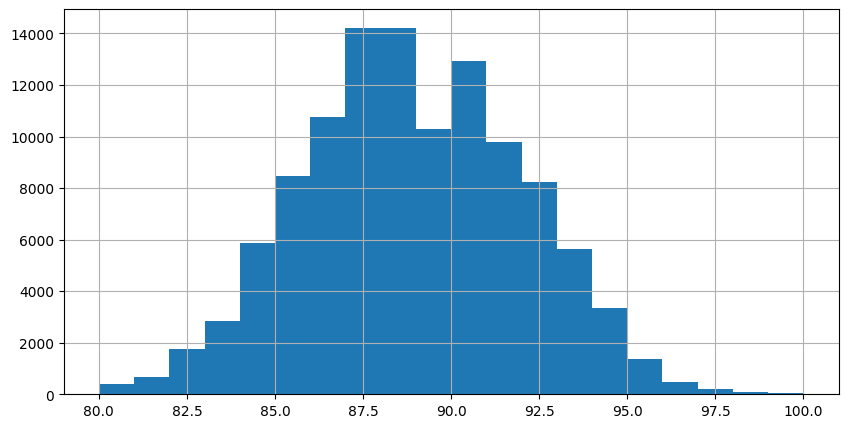

In [ ]:
print(wine_clean[wine_clean["points"].notnull()]["points"].unique())

histogram = wine_clean["points"].hist(bins=20, figsize=(10, 5))

## 2.4.78- Price Check

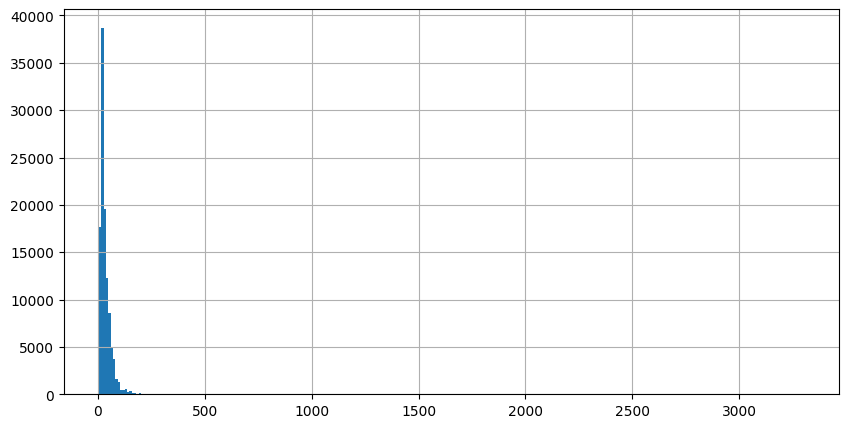

In [46]:
histogram = wine_clean["price"].hist(bins=300, figsize=(10, 5))

In [44]:
wine_clean["price"].max()


np.float64(3300.0)

## 3) Lowercase normalization

In [ ]:
# Lowercase normalization for all text columns to ensure consistency in the data.
text_columns = [
    "country", "description", "province",
    "region", "taster_name", "title",
    "variety", "winery"
]

for col in text_columns:
    wine_clean[col] = wine_clean[col].str.lower()

## 4) Remove extra whithespace

In [ ]:
# Remove extra spaces from the text columns to ensure consistency in the data.
for col in text_columns:
    wine_clean[col] = wine_clean[col].str.strip()

## 5) Reset index and create a Wine_id column


In [27]:
# Reset index after dropping duplicates and columns and create a new column "wine_id" with the index values.

wine_clean = wine_clean.reset_index(drop=True)

wine_clean.insert(0, "wine_id", wine_clean.index)

wine_clean.columns

Index(['wine_id', 'country', 'description', 'points', 'price', 'province',
       'region', 'taster_name', 'title', 'variety', 'winery'],
      dtype='object')

# 🍷 Reorder the columns and final output

In [29]:
desired_order = [
    "wine_id", "country",
    "title", "description",
    "variety","province","region",
    "price", "points", "taster_name"
]

wine_clean = wine_clean[desired_order]

In [30]:
wine_clean.head(10)

,wine_id,country,title,description,variety,province,region,price,points,taster_name
0,0,portugal,quinta dos avidagos 2011 avidagos red (douro),"this is ripe and fruity, a wine that is smooth...",portuguese red,douro,douro,15.0,87,roger voss
1,1,us,rainstorm 2013 pinot gris (willamette valley),"tart and snappy, the flavors of lime flesh and...",pinot gris,oregon,willamette valley,14.0,87,paul gregutt
2,2,us,st. julian 2013 reserve late harvest riesling ...,"pineapple rind, lemon pith and orange blossom ...",riesling,michigan,lake michigan shore,13.0,87,alexander peartree
3,3,us,sweet cheeks 2012 vintner's reserve wild child...,"much like the regular bottling from 2012, this...",pinot noir,oregon,willamette valley,65.0,87,paul gregutt
4,4,spain,tandem 2011 ars in vitro tempranillo-merlot (n...,blackberry and raspberry aromas show a typical...,tempranillo-merlot,northern spain,navarra,15.0,87,michael schachner
5,5,italy,terre di giurfo 2013 belsito frappato (vittoria),"here's a bright, informal red that opens with ...",frappato,sicily & sardinia,vittoria,16.0,87,kerin o'keefe
6,6,france,trimbach 2012 gewurztraminer (alsace),this dry and restrained wine offers spice in p...,gewürztraminer,alsace,alsace,24.0,87,roger voss
7,7,germany,heinz eifel 2013 shine gewürztraminer (rheinhe...,savory dried thyme notes accent sunnier flavor...,gewürztraminer,rheinhessen,rheinhessen,12.0,87,anna lee c. iijima
8,8,france,jean-baptiste adam 2012 les natures pinot gris...,this has great depth of flavor with its fresh ...,pinot gris,alsace,alsace,27.0,87,roger voss
9,9,us,kirkland signature 2011 mountain cuvée caberne...,"soft, supple plum envelopes an oaky structure ...",cabernet sauvignon,california,napa valley,19.0,87,virginie boone


In [31]:
wine_clean.columns

Index(['wine_id', 'country', 'title', 'description', 'variety', 'province',
       'region', 'price', 'points', 'taster_name'],
      dtype='object')

## 🎯 Output - Save file

In [33]:
# Save the clean file to a new CSV file (wine_clean.csv) in the data folder. The index is set to False to avoid saving the index as a separate column in the CSV file.

output_file = "../raw_data/wines_clean.csv"
wine_clean.to_csv(output_file, index=False)

print("=" * 60)
print(f"Clean file saved to: {output_file}")
print(f"Final number of wines: {len(wine_clean)}")
print("=" * 60)

Clean file saved to: ../raw_data/wines_clean.csv
Final number of wines: 111593
